In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [2]:
df = pd.read_csv("googleplaystore.csv")

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
print(df.shape)

(10841, 13)


In [5]:
print(df.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [7]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [8]:
df["Installs"] = (
    df["Installs"]
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False))

In [9]:
df["Installs"] = pd.to_numeric(
    df["Installs"],
    errors="coerce")

In [10]:
df["Size"] = df["Size"].replace(
    "Varies with device",
    np.nan)

In [11]:
def convert_size(size):
    if isinstance(size, str):
        if "M" in size:
            return float(size.replace("M", ""))
        elif "k" in size:
            return float(size.replace("k", "")) / 1000
    return np.nan
df["Size"] = df["Size"].apply(convert_size)

In [12]:
df["Price"] = (
    df["Price"]
    .str.replace("$", "", regex=False))

In [13]:
df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce")

In [14]:
df["Reviews"] = pd.to_numeric(
    df["Reviews"],
    errors="coerce")

In [16]:
df["Rating"] = (
    df.groupby("Category")["Rating"]
    .transform(lambda x: x.fillna(x.median())))

In [17]:
df["Size"] = (
    df.groupby("Category")["Size"]
    .transform(lambda x: x.fillna(x.median())))

In [18]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           1
Size              1
Installs          1
Type              1
Price             1
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64

In [19]:
df = (df.sort_values("Reviews", ascending=False)
    .drop_duplicates(subset="App"))

In [20]:
print(df.shape)

(9660, 13)


In [21]:
Q1 = df["Reviews"].quantile(0.25)
Q3 = df["Reviews"].quantile(0.75)
IQR = Q3 - Q1

In [22]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [23]:
review_outliers = df[
    (df["Reviews"] < lower) |
    (df["Reviews"] > upper)]
print(review_outliers.shape)

(1659, 13)


In [24]:
Q1_i = df["Installs"].quantile(0.25)
Q3_i = df["Installs"].quantile(0.75)
IQR_i = Q3_i - Q1_i
lower_i = Q1_i - 1.5 * IQR_i
upper_i = Q3_i + 1.5 * IQR_i

In [25]:
install_outliers = df[
    (df["Installs"] < lower_i) |
    (df["Installs"] > upper_i)]
print(install_outliers.shape)

(1981, 13)


In [26]:
outlier_category = (
    review_outliers
    .groupby("Category")
    .size()
    .reset_index(name="Outlier_Count")
    .sort_values(
        by="Outlier_Count",
        ascending=False))
print(outlier_category.head())

         Category  Outlier_Count
13           GAME            368
10         FAMILY            259
28          TOOLS            135
23    PHOTOGRAPHY            101
6   COMMUNICATION             84


In [27]:
category_benchmark = (
    df.groupby("Category")
    .agg({
        "Rating": "median",
        "Installs": "median"
    })
    .reset_index())
print(category_benchmark.head())

              Category  Rating  Installs
0                  1.9    19.0       NaN
1       ART_AND_DESIGN     4.4  100000.0
2    AUTO_AND_VEHICLES     4.3  100000.0
3               BEAUTY     4.3   50000.0
4  BOOKS_AND_REFERENCE     4.5   10000.0


In [28]:
type_dist = (
    df["Type"]
    .value_counts())
print(type_dist)

Type
Free    8904
Paid     754
0          1
Name: count, dtype: int64


In [29]:
type_category = pd.crosstab(
    df["Category"],
    df["Type"])
print(type_category.head())

Type                 0  Free  Paid
Category                          
1.9                  1     0     0
ART_AND_DESIGN       0    58     3
AUTO_AND_VEHICLES    0    82     3
BEAUTY               0    53     0
BOOKS_AND_REFERENCE  0   194    28


In [30]:
type_compare = (
    df.groupby("Type")
    .agg({
        "Rating": "median",
        "Installs": "median",
        "Reviews": "median"}))
print(type_compare)

      Rating  Installs  Reviews
Type                           
0      19.00       NaN      NaN
Free    4.30  100000.0   1379.5
Paid    4.35    1000.0     88.5


In [31]:
top_categories = (
    df.groupby("Category")
    .agg({
        "Rating": "median",
        "Installs": "median"
    })
    .sort_values(
        by=["Rating", "Installs"],
        ascending=False)
    .head(5))
print(top_categories)

                     Rating   Installs
Category                              
1.9                    19.0        NaN
HEALTH_AND_FITNESS      4.5   100000.0
BOOKS_AND_REFERENCE     4.5    10000.0
EVENTS                  4.5     1000.0
EDUCATION               4.4  1000000.0


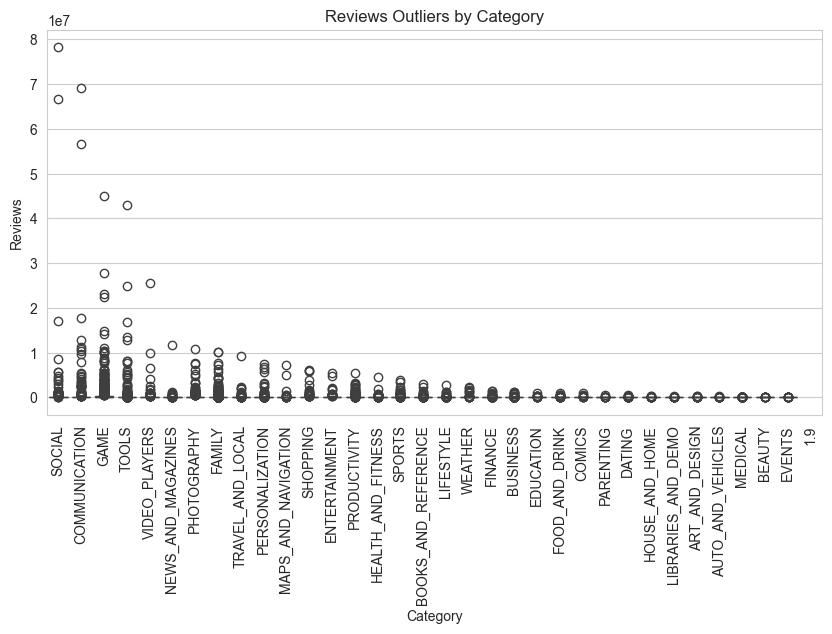

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="Category",
    y="Reviews")
plt.xticks(rotation=90)
plt.title("Reviews Outliers by Category")
plt.show()

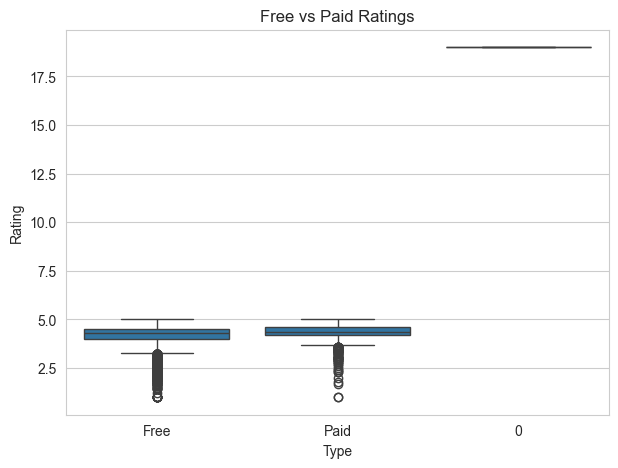

In [34]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Type",
    y="Rating")
plt.title("Free vs Paid Ratings")
plt.show()

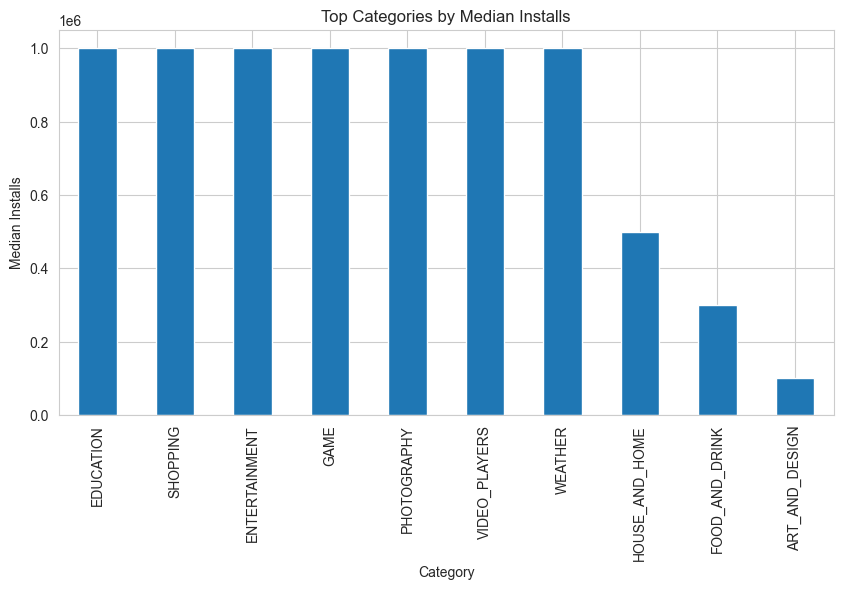

In [36]:
median_installs = (
    df.groupby("Category")["Installs"]
    .median()
    .sort_values(ascending=False)
    .head(10))
median_installs.plot(
    kind="bar",
    figsize=(10,5))
plt.title("Top Categories by Median Installs")
plt.ylabel("Median Installs")
plt.show()

In [37]:
raw_df = pd.read_csv("googleplaystore.csv")

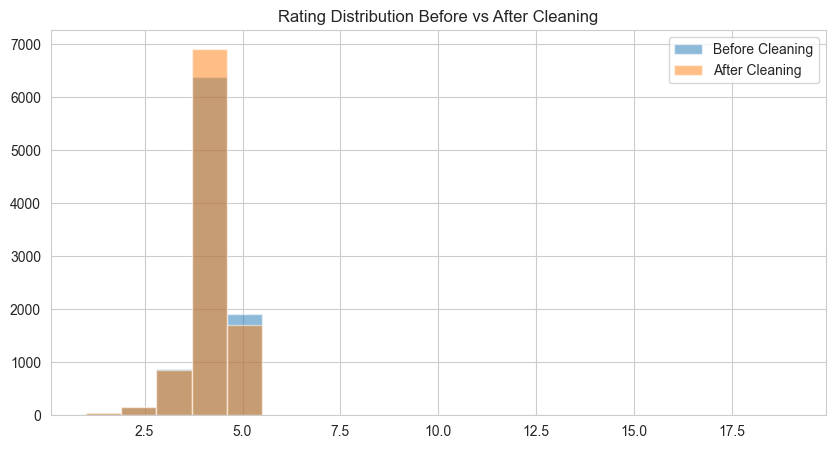

In [39]:
plt.figure(figsize=(10,5))
plt.hist(
    raw_df["Rating"].dropna(),
    bins=20,
    alpha=0.5,
    label="Before Cleaning")
plt.hist(
    df["Rating"].dropna(),
    bins=20,
    alpha=0.5,
    label="After Cleaning")
plt.legend()
plt.title("Rating Distribution Before vs After Cleaning")
plt.show()

In [40]:
bubble_df = (
    df.groupby("Category")
    .agg({
        "Rating": "median",
        "Installs": "median",
        "App": "count"})
    .reset_index())
bubble_df["Log_Installs"] = np.log10(
    bubble_df["Installs"] + 1) #bonus

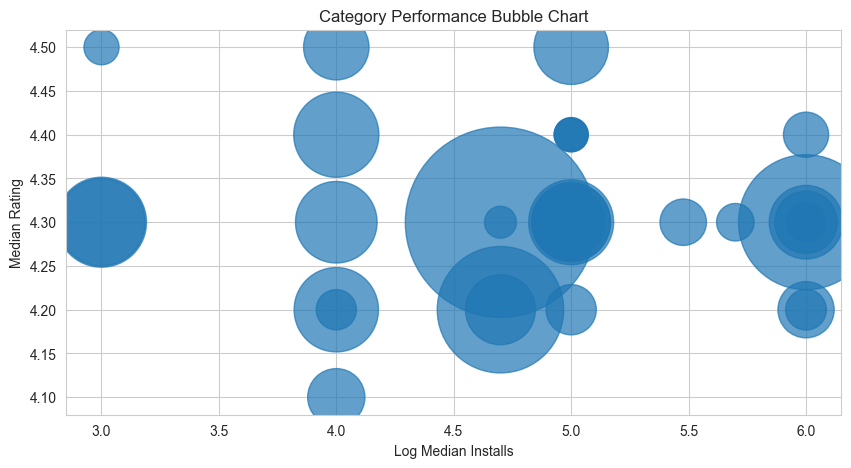

In [42]:
plt.figure(figsize=(10,5))
plt.scatter(
    bubble_df["Log_Installs"],
    bubble_df["Rating"],
    s=bubble_df["App"] * 10,
    alpha=0.7)
plt.xlabel("Log Median Installs")
plt.ylabel("Median Rating")
plt.title("Category Performance Bubble Chart")
plt.show()

In [43]:
paid_advantage = (
    df.groupby(["Category", "Type"])["Rating"]
    .median()
    .unstack())
paid_advantage["Difference"] = (
    paid_advantage["Paid"] -
    paid_advantage["Free"])
paid_advantage = (
    paid_advantage
    .sort_values(
        by="Difference",
        ascending=False))
print(paid_advantage.head())

Type                 0  Free  Paid  Difference
Category                                      
NEWS_AND_MAGAZINES NaN   4.2   4.8         0.6
EDUCATION          NaN   4.4   4.8         0.4
ENTERTAINMENT      NaN   4.2   4.6         0.4
ART_AND_DESIGN     NaN   4.4   4.7         0.3
SHOPPING           NaN   4.3   4.5         0.2
